<a href="https://colab.research.google.com/github/ziadabdullah007/Deep_Learning_Project/blob/main/bilstm_efficientnetb0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================================
# CNN FEATURE EXTRACTION
# AI MENU DESCRIPTION + FOOD RECOMMENDATION
# KAGGLE VERSION
# EfficientNetB0
# =========================================

import pandas as pd
import numpy as np
import os
import pickle

from tqdm import tqdm

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

from tensorflow.keras.preprocessing.image import (
    load_img,
    img_to_array
)

from tensorflow.keras.models import Model


# ======================================================
# 1. LOAD DATASET
# ======================================================

df = pd.read_csv(
    "/kaggle/input/datasets/ziadabdullah000/data111/final_food_data/final_refined_food_dataset.csv"
)

print("DATASET SHAPE:")
print(df.shape)


# ======================================================
# 2. FIX IMAGE PATHS FOR KAGGLE
# ======================================================

images_folder = (
    "/kaggle/input/datasets/ziadabdullah000/data111/final_food_data/all_images/"
)

# إصلاح المسارات
df["image_path"] = df["image_path"].apply(
    lambda x: os.path.join(
        images_folder,
        os.path.basename(x)
    )
)


# ======================================================
# 3. LOAD PRETRAINED CNN MODEL
# ======================================================

# remove final classification layer

base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    pooling="avg"
)

model = Model(
    inputs=base_model.input,
    outputs=base_model.output
)

print("\nCNN MODEL LOADED ✅")


# ======================================================
# 4. FEATURE EXTRACTION FUNCTION
# ======================================================

def extract_features(img_path):

    try:

        # load image
        img = load_img(
            img_path,
            target_size=(224, 224)
        )

        # image to array
        img = img_to_array(img)

        # add batch dimension
        img = np.expand_dims(img, axis=0)

        # preprocess for EfficientNet
        img = preprocess_input(img)

        # extract features
        features = model.predict(
            img,
            verbose=0
        )

        # flatten vector
        features = features.flatten()

        return features

    except Exception as e:

        print(f"\nERROR WITH IMAGE:")
        print(img_path)

        return None


# ======================================================
# 5. EXTRACT FEATURES FROM ALL IMAGES
# ======================================================

features_dict = {}

print("\nEXTRACTING FEATURES...\n")

for idx, row in tqdm(
    df.iterrows(),
    total=len(df)
):

    img_path = row["image_path"]

    features = extract_features(img_path)

    if features is not None:

        image_name = os.path.basename(img_path)

        features_dict[image_name] = features


# ======================================================
# 6. SAVE FEATURES
# ======================================================

save_path = "/kaggle/working/features.pkl"

with open(save_path, "wb") as f:

    pickle.dump(features_dict, f)

print("\nFEATURES SAVED ✅")

print(save_path)


# ======================================================
# 7. SHOW SAMPLE OUTPUT
# ======================================================

sample_key = list(features_dict.keys())[0]

print("\nSAMPLE IMAGE:")
print(sample_key)

print("\nFEATURE VECTOR SHAPE:")
print(features_dict[sample_key].shape)

print("\nFIRST 20 FEATURES:")
print(features_dict[sample_key][:20])


# ======================================================
# 8. TOTAL FEATURES EXTRACTED
# ======================================================

print("\nTOTAL IMAGES PROCESSED:")
print(len(features_dict))

DATASET SHAPE:
(21127, 8)


I0000 00:00:1778418044.580360      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778418044.586312      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

CNN MODEL LOADED ✅

EXTRACTING FEATURES...



  0%|          | 0/21127 [00:00<?, ?it/s]WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
I0000 00:00:1778418049.577796     131 service.cc:152] XLA service 0x7cfe840039f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778418049.577843     131 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778418049.577849     131 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778418050.457450     131 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-10 13:00:56.124298: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 13:00:56.258492: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy


FEATURES SAVED ✅
/kaggle/working/features.pkl

SAMPLE IMAGE:
img_0.jpg

FEATURE VECTOR SHAPE:
(1280,)

FIRST 20 FEATURES:
[ 0.32068336  0.27295724 -0.0357395  -0.15958719 -0.10290971 -0.09633916
  0.2678807  -0.15771402 -0.02996683 -0.05463921 -0.05474378 -0.10637458
  0.10561977 -0.08878174 -0.06840337 -0.07158731 -0.094452    0.2394211
 -0.08211798 -0.11289032]

TOTAL IMAGES PROCESSED:
21127


In [ ]:
# =========================================
# RNN / BiLSTM TRAINING V2
# IMPROVED AI MENU DESCRIPTION GENERATOR
# =========================================

import pandas as pd
import numpy as np
import pickle
import re

from tqdm import tqdm

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Model

from tensorflow.keras.layers import (
    Input,
    Dense,
    LSTM,
    Embedding,
    Dropout,
    add,
    Bidirectional,
    BatchNormalization
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)

from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split


# ======================================================
# 1. LOAD DATASET
# ======================================================

df = pd.read_csv(
    "/kaggle/input/datasets/ziadabdullah000/data111/final_food_data/final_refined_food_dataset.csv"
)

print("DATASET SHAPE:")
print(df.shape)


# ======================================================
# 2. LOAD CNN FEATURES
# ======================================================

with open(
    "/kaggle/working/features.pkl",
    "rb"
) as f:

    features = pickle.load(f)

print("\nFEATURES LOADED ✅")

print("TOTAL FEATURES:")
print(len(features))


# ======================================================
# 3. CREATE SHORT VISUAL CAPTIONS
# ======================================================

def clean_ingredient(text):

    text = str(text).lower()

    text = re.sub(r'\d+', '', text)

    text = re.sub(r'[^a-zA-Z, ]', '', text)

    return text.strip()


def create_short_caption(row):

    title = str(row["title"]).lower()

    ingredients = str(row["ingredients"]).split("|")

    ingredients = [
        clean_ingredient(x)
        for x in ingredients
    ]

    ingredients = [
        x for x in ingredients
        if len(x.strip()) > 2
    ]

    # top 3 ingredients only
    ingredients = ingredients[:3]

    ingredients_text = ", ".join(ingredients)

    caption = (
        f"<start> {title} with {ingredients_text} <end>"
    )

    return caption


# create captions
df["refined_caption"] = df.apply(
    create_short_caption,
    axis=1
)

print("\nSHORT VISUAL CAPTIONS CREATED ✅")


# ======================================================
# SHOW SAMPLE CAPTIONS
# ======================================================

for i in range(5):

    print("\n" + "=" * 60)

    print(df["refined_caption"].iloc[i])


# ======================================================
# 4. TOKENIZER
# ======================================================

captions = df["refined_caption"].tolist()

tokenizer = Tokenizer(
    oov_token="<unk>"
)

tokenizer.fit_on_texts(captions)

vocab_size = len(tokenizer.word_index) + 1

print("\nVOCAB SIZE:")
print(vocab_size)


# ======================================================
# 5. MAX LENGTH
# ======================================================

max_length = 20

print("\nMAX LENGTH:")
print(max_length)


# ======================================================
# 6. CREATE TRAINING DATA
# ======================================================

X1 = []

X2 = []

y = []

print("\nCREATING TRAINING DATA...\n")

for idx, row in tqdm(
    df.iterrows(),
    total=len(df)
):

    image_name = row["image_path"].split("/")[-1]

    caption = row["refined_caption"]

    # skip missing features
    if image_name not in features:
        continue

    image_features = features[image_name]

    # caption -> sequence
    seq = tokenizer.texts_to_sequences(
        [caption]
    )[0]

    # create training samples
    for i in range(1, len(seq)):

        in_seq = seq[:i]

        out_seq = seq[i]

        in_seq = pad_sequences(
            [in_seq],
            maxlen=max_length
        )[0]

        X1.append(image_features)

        X2.append(in_seq)

        y.append(out_seq)


# ======================================================
# 7. CONVERT TO NUMPY
# ======================================================

X1 = np.array(
    X1,
    dtype=np.float32
)

X2 = np.array(
    X2,
    dtype=np.int32
)

y = np.array(
    y,
    dtype=np.int32
)

print("\nTRAINING SHAPES:")

print("IMAGE FEATURES:", X1.shape)

print("TEXT INPUT:", X2.shape)

print("TARGET:", y.shape)


# ======================================================
# 8. TRAIN TEST SPLIT
# ======================================================

X1_train, X1_val, X2_train, X2_val, y_train, y_val = train_test_split(

    X1,
    X2,
    y,

    test_size=0.1,

    random_state=42
)

print("\nTRAIN TEST SPLIT DONE ✅")


# ======================================================
# 9. IMAGE FEATURE BRANCH
# ======================================================

inputs1 = Input(shape=(1280,))

fe1 = Dropout(0.5)(inputs1)

fe2 = Dense(
    512,
    activation='relu'
)(fe1)

fe2 = BatchNormalization()(fe2)

fe2 = Dropout(0.3)(fe2)


# ======================================================
# 10. TEXT BRANCH
# ======================================================

inputs2 = Input(shape=(max_length,))

se1 = Embedding(

    vocab_size,

    512,

    mask_zero=False

)(inputs2)

se2 = Dropout(0.5)(se1)

se3 = Bidirectional(
    LSTM(256)
)(se2)

se3 = Dropout(0.3)(se3)


# ======================================================
# 11. MERGE BRANCHES
# ======================================================

decoder1 = add([fe2, se3])

decoder2 = Dense(
    512,
    activation='relu'
)(decoder1)

decoder2 = BatchNormalization()(decoder2)

decoder2 = Dropout(0.4)(decoder2)

outputs = Dense(

    vocab_size,

    activation='softmax'

)(decoder2)


# ======================================================
# 12. BUILD MODEL
# ======================================================

model = Model(

    inputs=[inputs1, inputs2],

    outputs=outputs
)

optimizer = Adam(
    learning_rate=0.0003
)

model.compile(

    loss='sparse_categorical_crossentropy',

    optimizer=optimizer,

    metrics=['accuracy']
)

print("\nMODEL SUMMARY:\n")

model.summary()


# ======================================================
# 13. CALLBACKS
# ======================================================

checkpoint = ModelCheckpoint(

    "/kaggle/working/best_model.keras",

    monitor="val_loss",

    save_best_only=True,

    verbose=1
)

early_stop = EarlyStopping(

    monitor="val_loss",

    patience=4,

    restore_best_weights=True
)


# ======================================================
# 14. TRAIN MODEL
# ======================================================

history = model.fit(

    [X1_train, X2_train],

    y_train,

    validation_data=(
        [X1_val, X2_val],
        y_val
    ),

    epochs=20,

    batch_size=128,

    callbacks=[
        checkpoint,
        early_stop
    ]
)


# ======================================================
# 15. SAVE TOKENIZER
# ======================================================

with open(
    "/kaggle/working/tokenizer.pkl",
    "wb"
) as f:

    pickle.dump(tokenizer, f)

print("\nTOKENIZER SAVED ✅")


# ======================================================
# 16. SAVE MODEL
# ======================================================

model.save(
    "/kaggle/working/final_model.keras"
)

print("\nMODEL SAVED ✅")


# ======================================================
# 17. FINAL INFO
# ======================================================

print("\nTRAINING COMPLETE 🔥")

print("\nFILES SAVED:")

print("/kaggle/working/final_model.keras")

print("/kaggle/working/tokenizer.pkl")

print("/kaggle/working/features.pkl")

DATASET SHAPE:
(21127, 8)

FEATURES LOADED ✅
TOTAL FEATURES:
21127

SHORT VISUAL CAPTIONS CREATED ✅

<start> beer-battered pollock bites with g pollock fillets, skinned and cut into bitesize chunks, sunflower or vegetable oil, lime wedges, to serve <end>

<start> cooking with kids: spaghetti & meatballs with hidden veg sauce with g good quality pork sausage about  large or  chipolatas, g lean beef mince, small onion coarsely grated <end>

<start> smoked mackerel with herb & beet couscous with g couscous, tsp horseradish sauce, g pot  fat greek yogurt <end>

<start> mussels in white wine sauce with garlic butter toasts with slices sourdough bread, tbsp olive oil, knob of butter <end>

<start> saag aloo with tbsp sunflower oil, onion finely chopped, garlic cloves sliced <end>

VOCAB SIZE:
11617

MAX LENGTH:
20

CREATING TRAINING DATA...



100%|██████████| 21127/21127 [00:11<00:00, 1772.43it/s]



TRAINING SHAPES:
IMAGE FEATURES: (927997, 1280)
TEXT INPUT: (927997, 20)
TARGET: (927997,)

TRAIN TEST SPLIT DONE ✅

MODEL SUMMARY:



Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 1280)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1280)      │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 20, 512)   │  5,947,904 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │    655,872 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 20, 512)   │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 512)       │      2,048 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 512)       │  1,574,912 │ dropout_2[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 512)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 512)       │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 512)       │          0 │ dropout_1[0][0],  │
│                     │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 512)       │    262,656 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 512)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 11617)     │  5,959,521 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,404,961 (54.95 MB)

 Trainable params: 14,402,913 (54.94 MB)

 Non-trainable params: 2,048 (8.00 KB)

Epoch 1/20
6525/6525 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.0892 - loss: 6.2527
Epoch 1: val_loss improved from inf to 4.34725, saving model to /kaggle/working/best_model.keras
6525/6525 ━━━━━━━━━━━━━━━━━━━━ 184s 27ms/step - accuracy: 0.0892 - loss: 6.2526 - val_accuracy: 0.2418 - val_loss: 4.3472
Epoch 2/20
6525/6525 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.2334 - loss: 4.3604
Epoch 2: val_loss improved from 4.34725 to 3.80034, saving model to /kaggle/working/best_model.keras
6525/6525 ━━━━━━━━━━━━━━━━━━━━ 176s 27ms/step - accuracy: 0.2334 - loss: 4.3604 - val_accuracy: 0.3058 - val_loss: 3.8003
Epoch 3/20
6524/6525 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.2879 - loss: 3.8778
Epoch 3: val_loss improved from 3.80034 to 3.54918, saving model to /kaggle/working/best_model.keras
6525/6525 ━━━━━━━━━━━━━━━━━━━━ 177s 27ms/step - accuracy: 0.2879 - loss: 3.8777 - val_accuracy: 0.3356 - val_loss: 3.5492
Epoch 4/20
6524/6525 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0

MODEL LOADED ✅
TOKENIZER LOADED ✅
FEATURES LOADED ✅
DATASET LOADED ✅
CNN LOADED ✅
FEATURES EXTRACTED ✅


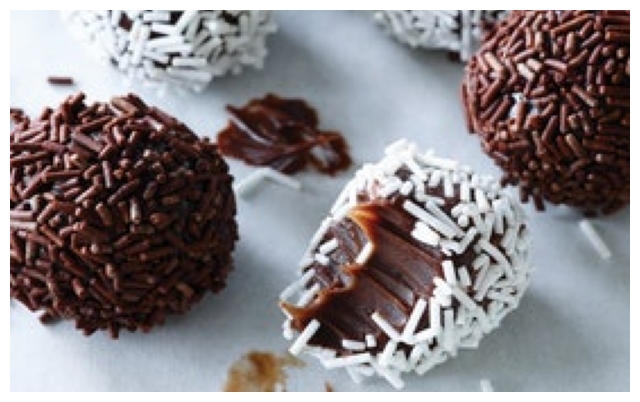

AI MENU DESCRIPTION 🔥

Chocolate chip chocolate cookies with ounces bittersweet.

RECOMMENDED DISHES 🔥

1. Brigadeiros
2. Quick Double-Chocolate Sheet Cake
3. Pecan-Rye Pumpkin Pie
4. Flourless Apple, Almond, and Ginger Cake
5. Flourless Chocolate-Walnut Cookies


In [ ]:
# =========================================
# FOOD IMAGE CAPTION GENERATION
# + FOOD RECOMMENDATION SYSTEM
# FINAL IMPROVED VERSION
# =========================================

import numpy as np
import pickle
import matplotlib.pyplot as plt
import pandas as pd

from PIL import Image

from tensorflow.keras.models import load_model

from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

from tensorflow.keras.preprocessing.image import (
    load_img,
    img_to_array
)

from sklearn.metrics.pairwise import cosine_similarity


# ======================================================
# 1. LOAD MODEL
# ======================================================

model = load_model(
    "/kaggle/working/final_model.keras"
)

print("MODEL LOADED ✅")


# ======================================================
# 2. LOAD TOKENIZER
# ======================================================

with open(
    "/kaggle/working/tokenizer.pkl",
    "rb"
) as f:

    tokenizer = pickle.load(f)

print("TOKENIZER LOADED ✅")


# ======================================================
# 3. LOAD FEATURES
# ======================================================

with open(
    "/kaggle/working/features.pkl",
    "rb"
) as f:

    features = pickle.load(f)

print("FEATURES LOADED ✅")


# ======================================================
# 4. LOAD DATASET
# ======================================================

df = pd.read_csv(
    "/kaggle/input/datasets/ziadabdullah000/data111/final_food_data/final_refined_food_dataset.csv"
)

print("DATASET LOADED ✅")


# ======================================================
# 5. MAX LENGTH
# IMPORTANT:
# SAME VALUE USED IN TRAINING
# ======================================================

max_length = 20


# ======================================================
# 6. CNN MODEL
# ======================================================

cnn_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    pooling='avg'
)

print("CNN LOADED ✅")


# ======================================================
# 7. IMAGE FEATURE EXTRACTION
# ======================================================

def extract_features(img_path):

    img = load_img(
        img_path,
        target_size=(224, 224)
    )

    img = img_to_array(img)

    img = np.expand_dims(img, axis=0)

    img = preprocess_input(img)

    features = cnn_model.predict(
        img,
        verbose=0
    )

    return features.flatten()


# ======================================================
# 8. INDEX -> WORD
# ======================================================

def idx_to_word(integer, tokenizer):

    for word, index in tokenizer.word_index.items():

        if index == integer:
            return word

    return None


# ======================================================
# 9. GENERATE CAPTION
# ======================================================

def generate_caption(model, tokenizer, photo, max_length):

    in_text = '<start>'

    used_words = []

    for i in range(20):

        sequence = tokenizer.texts_to_sequences(
            [in_text]
        )[0]

        sequence = pad_sequences(
            [sequence],
            maxlen=max_length
        )

        yhat = model.predict(
            [photo.reshape(1, 1280), sequence],
            verbose=0
        )

        # probabilities
        yhat_probs = yhat[0]

        # temperature sampling
        temperature = 0.7

        yhat_probs = np.log(
            yhat_probs + 1e-10
        ) / temperature

        exp_preds = np.exp(yhat_probs)

        yhat_probs = exp_preds / np.sum(exp_preds)

        # sample word
        yhat = np.random.choice(
            len(yhat_probs),
            p=yhat_probs
        )

        word = idx_to_word(
            yhat,
            tokenizer
        )

        if word is None:
            break

        # stop too much repetition
        if used_words.count(word) >= 2:
            break

        used_words.append(word)

        in_text += ' ' + word

        if word == '<end>':
            break

    return in_text


# ======================================================
# 10. CLEAN CAPTION
# ======================================================

def clean_caption(caption):

    # remove tokens
    caption = caption.replace('<start>', '')

    caption = caption.replace('<end>', '')

    caption = caption.lower()

    words = caption.split()

    cleaned_words = []

    for word in words:

        # remove direct repetition
        if len(cleaned_words) > 0:

            if word == cleaned_words[-1]:
                continue

        cleaned_words.append(word)

    # allow max 2 repeats
    final_words = []

    word_counts = {}

    for word in cleaned_words:

        if word not in word_counts:
            word_counts[word] = 0

        if word_counts[word] < 2:

            final_words.append(word)

            word_counts[word] += 1

    # limit length
    final_words = final_words[:20]

    caption = " ".join(final_words)

    caption = caption.capitalize()

    if not caption.endswith("."):
        caption += "."

    return caption


# ======================================================
# 11. RECOMMEND SIMILAR DISHES
# ======================================================

def recommend_dishes(query_features, features_dict, top_n=5):

    image_names = list(features_dict.keys())

    feature_vectors = np.array(
        list(features_dict.values())
    )

    similarities = cosine_similarity(
        [query_features],
        feature_vectors
    )[0]

    top_indices = similarities.argsort()[-top_n:][::-1]

    recommendations = []

    for idx in top_indices:

        image_name = image_names[idx]

        matched_row = df[
            df['image_path'].str.contains(image_name)
        ]

        if len(matched_row) > 0:

            title = matched_row.iloc[0]['title']

            recommendations.append(title)

    return recommendations


# ======================================================
# 12. TEST IMAGE
# ======================================================

test_image = (
    "/kaggle/input/datasets/ziadabdullah000/data111/final_food_data/all_images/img_10114.jpg"
)


# ======================================================
# 13. EXTRACT FEATURES
# ======================================================

query_features = extract_features(
    test_image
)

print("FEATURES EXTRACTED ✅")


# ======================================================
# 14. GENERATE CAPTION
# ======================================================

raw_caption = generate_caption(

    model,
    tokenizer,
    query_features,
    max_length
)

caption = clean_caption(
    raw_caption
)


# ======================================================
# 15. RECOMMENDATIONS
# ======================================================

recommendations = recommend_dishes(

    query_features,
    features,
    top_n=5
)


# ======================================================
# 16. DISPLAY RESULTS
# ======================================================

img = Image.open(test_image)

plt.figure(figsize=(8, 8))

plt.imshow(img)

plt.axis('off')

plt.show()


print("=" * 60)

print("AI MENU DESCRIPTION 🔥\n")

print(caption)


print("\n" + "=" * 60)

print("RECOMMENDED DISHES 🔥\n")

for i, rec in enumerate(recommendations, 1):

    print(f"{i}. {rec}")